In [21]:
# data source : https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data?resource=download
import pandas as pd
import numpy as np
import pandera.pandas as pa
from pandera.errors import SchemaErrors
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Phase 1
# Load the CSV file into a DataFrame
file_name = "Extended_Employee_Performance_and_Productivity_Data.csv"
df = pd.read_csv(file_name)


In [4]:
# Data Summary
def Data_summary(df):
    """
    Analyzes a pandas DataFrame and returns a summary of missing data, 
    total counts, data types, column names, and original column numbers.
    """
    # 1. Total data (number of rows)
    total_data = len(df)
    # 2. Count of missing values per column
    missing_data = df.isnull().sum()
    
    # 3. Count of non-missing values per column
    not_missing_data = df.notnull().sum()
    
    # 4. Data types for each column
    data_types = df.dtypes
    
    # 5. Percentage of missing data per column
    missing_percentage = (missing_data / total_data) * 100
    
    # 6. Original Column Numbers (1-indexed for readability)
    column_numbers = range(1, len(df.columns) + 1)
    
    # Combine everything into a new summary DataFrame
    summary_df = pd.DataFrame({
        'Column No.': column_numbers,
        'Total Rows': total_data,
        'Not Missing': not_missing_data,
        'Missing Values': missing_data,
        'Missing %': missing_percentage.round(2),
        'Data Type': data_types
    })
    
    # Pull the column names out of the index and into a proper column
    summary_df = summary_df.reset_index()
    summary_df = summary_df.rename(columns={'index': 'Column Name'})
    
    # --- Sorting data according to column no ---
    # Sort the DataFrame by the original column number (1, 2, 3...)
    summary_df = summary_df.sort_values(by='Column No.', ascending=True)
    
    # Reset the index so the row labels are clean (0, 1, 2, 3...)
    summary_df = summary_df.reset_index(drop=True)
    
    # Reorder the final DataFrame columns for perfect readability
    summary_df = summary_df[['Column No.', 'Column Name', 'Total Rows', 
                             'Not Missing', 'Missing Values', 'Missing %', 'Data Type']]
    
    return summary_df


# summary of the data
Data_summary(df)


,Column No.,Column Name,Total Rows,Not Missing,Missing Values,Missing %,Data Type
0,1,Employee_ID,100000,100000,0,0.00,int64
1,2,Department,100000,100000,0,0.00,object
2,3,Gender,100000,100000,0,0.00,object
3,4,Age,100000,100000,0,0.00,int64
4,5,Job_Title,100000,100000,0,0.00,object
5,6,Hire_Date,100000,100000,0,0.00,object
6,7,Years_At_Company,100000,95953,4047,4.05,float64
7,8,Education_Level,100000,100000,0,0.00,object
8,9,Performance_Score,100000,95989,4011,4.01,float64
9,10,Monthly_Salary,100000,95970,4030,4.03,float64


In [5]:
# Drop any row that contains a missing value
df_cleaned =len( df.dropna())
# Verify the results

# Total data
print(f"Original Rows: {len(df)}")

# Total cleaned data
print(f"Cleaned Rows: {(df_cleaned)}")


total_missing = len(df)-df_cleaned

# Total percentage of missing data
print(f"Total Missing Percentage: {100*total_missing/len(df)}%")

Original Rows: 100000
Cleaned Rows: 63651
Total Missing Percentage: 36.349%


In [6]:

# List of numeric columns with missing values based on your summary
missing_numeric_cols = [
    'Years_At_Company', 'Performance_Score', 'Monthly_Salary', 
    'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 
    'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 
    'Training_Hours', 'Employee_Satisfaction_Score'
]

# Impute missing values with the median of each column
for col in missing_numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Verify the recovery
print(f"Total Rows after Median Imputation: {len(df)}")
print("\nMissing values remaining:")
print(df[missing_numeric_cols].isnull().sum())


Total Rows after Median Imputation: 100000

Missing values remaining:
Years_At_Company               0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Employee_Satisfaction_Score    0
dtype: int64


In [7]:
# summary of modified / updated data
Data_summary(df)

,Column No.,Column Name,Total Rows,Not Missing,Missing Values,Missing %,Data Type
0,1,Employee_ID,100000,100000,0,0.0,int64
1,2,Department,100000,100000,0,0.0,object
2,3,Gender,100000,100000,0,0.0,object
3,4,Age,100000,100000,0,0.0,int64
4,5,Job_Title,100000,100000,0,0.0,object
5,6,Hire_Date,100000,100000,0,0.0,object
6,7,Years_At_Company,100000,100000,0,0.0,float64
7,8,Education_Level,100000,100000,0,0.0,object
8,9,Performance_Score,100000,100000,0,0.0,float64
9,10,Monthly_Salary,100000,100000,0,0.0,float64


In [8]:
# detecting the outlairs
def count_outliers_iqr(df, columns):
    """
    Calculates the IQR boundaries for a list of columns and returns 
    a summary DataFrame of the outlier counts.
    """
    outlier_counts = {}
    
    for col in columns:
        # Calculate percentiles and IQR
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define the strict mathematical boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Isolate the anomalies
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
        
    # Convert results into a clean DataFrame
    summary_df = pd.DataFrame(list(outlier_counts.items()), columns=['Column Name', 'Outlier Count'])
    summary_df = summary_df.sort_values(by='Outlier Count', ascending=False).reset_index(drop=True)
    
    return summary_df
    
# We will use the same numeric columns you just imputed
numeric_cols_to_check = [
    'Years_At_Company', 'Performance_Score', 'Monthly_Salary', 
    'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 
    'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 
    'Training_Hours', 'Employee_Satisfaction_Score'
]

outlier_summary = count_outliers_iqr(df, numeric_cols_to_check)
print(outlier_summary)

                    Column Name  Outlier Count
0                Monthly_Salary            174
1              Years_At_Company              0
2             Performance_Score              0
3           Work_Hours_Per_Week              0
4              Projects_Handled              0
5                Overtime_Hours              0
6                     Sick_Days              0
7         Remote_Work_Frequency              0
8                     Team_Size              0
9                Training_Hours              0
10  Employee_Satisfaction_Score              0


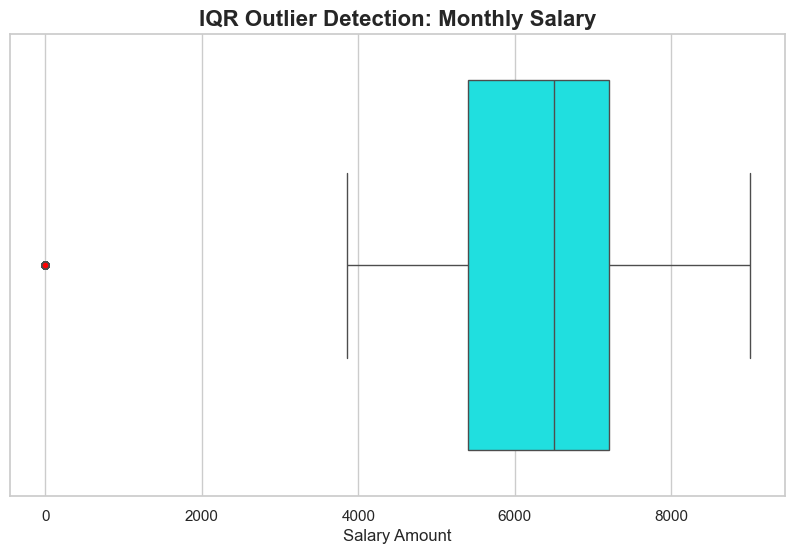

In [10]:


# Set the size and style of the figure
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the box plot for Monthly_Salary
sns.boxplot(x=df['Monthly_Salary'], color='cyan', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5})

# Add mathematical clarity to the titles and labels
plt.title('IQR Outlier Detection: Monthly Salary', fontsize=16, fontweight='bold')
plt.xlabel('Salary Amount', fontsize=12)

# Display the plot
plt.show()

In [43]:

# 1. Recalculate your boundaries just to be safe
Q1 = df['Monthly_Salary'].quantile(0.25)
Q3 = df['Monthly_Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Cap the outliers using numpy's 'where' function
df['Monthly_Salary'] = np.where(df['Monthly_Salary'] > upper_bound, upper_bound, 
                       np.where(df['Monthly_Salary'] < lower_bound, lower_bound, 
                       df['Monthly_Salary']))

print("Outliers capped successfully at IQR boundaries.")
outlier_summary = count_outliers_iqr(df, numeric_cols_to_check)
print(outlier_summary)


Outliers capped successfully at IQR boundaries.
                    Column Name  Outlier Count
0              Years_At_Company              0
1             Performance_Score              0
2                Monthly_Salary              0
3           Work_Hours_Per_Week              0
4              Projects_Handled              0
5                Overtime_Hours              0
6                     Sick_Days              0
7         Remote_Work_Frequency              0
8                     Team_Size              0
9                Training_Hours              0
10  Employee_Satisfaction_Score              0


In [14]:
# Phase 2
# Identify categorical columns (excluding the target variable 'Resigned')
categorical_cols = ['Department', 'Gender', 'Job_Title', 'Education_Level']

# Apply One-Hot Encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print(f"Categorical translation complete. New feature count: {df_encoded.shape[1]}")


Categorical translation complete. New feature count: 35


In [16]:

# Step 1: Build the Absolute Correlation Matrix 
# Drop both the target variable ('Resigned') AND the unformatted string column ('Hire_Date')
features = df_encoded.drop(columns=['Resigned', 'Hire_Date'])
corr_matrix = features.corr().abs()

# Step 2: Isolate the Upper Triangle
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: Identify Pairs > 0.80
collinear_pairs = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.80)]
print(f"Highly collinear features identified for review: {collinear_pairs}")

# Step 4: Target Comparison
target_corr = df_encoded.drop(columns=['Hire_Date']).corr()['Resigned'].abs()
print("\nCorrelation with Target Variable ('Resigned'):")
for feature in collinear_pairs:
    print(f"{feature}: {target_corr[feature]:.4f}")

Highly collinear features identified for review: []

Correlation with Target Variable ('Resigned'):


In [22]:
# phase 3


# 1. Define the explicit data contract
schema = pa.DataFrameSchema(
    {
        # Enforcing datatypes and statistical boundaries
        "Age": pa.Column(int, pa.Check.ge(18), nullable=False), 
        "Years_At_Company": pa.Column(float, pa.Check.ge(0.0), nullable=False), 
        "Monthly_Salary": pa.Column(float, pa.Check.ge(0.0), nullable=False),
        "Performance_Score": pa.Column(float, pa.Check.in_range(1.0, 5.0), nullable=False),
        "Resigned": pa.Column(bool, nullable=False)
    },
    # strict=False allows your dynamically generated One-Hot Encoded columns to pass through safely
    strict=False 
)

# 2. Execute Lazy Validation
try:
    # Setting lazy=True processes the entire dataframe and collects all structural failures
    validated_df = schema.validate(df_encoded, lazy=True)
    print("Data Integrity Vault: Validation Passed. Data is cleared for the Feature Store.")
    
except SchemaErrors as err:
    print("CRITICAL: Data Contract Violated. Pipeline halted.")
    # Generates the single diagnostic report keeping the pipeline running for valid data
    print(err.failure_cases)

Data Integrity Vault: Validation Passed. Data is cleared for the Feature Store.
